# 08 · Evaluate the SBI posterior trained on the CL latents

Uses `config.EVAL["n_samples"]` posterior samples per observation on
* **val**: the v1 + v2 validation sets (in distribution),
* **test**: the C-grid set (every cosmology on a regular grid of C over its full prior).

**Sampling is the slow step.** For full-size runs, do it from a terminal first (resumable, bounded memory):

```bash
nohup python -m clmini.sample_posteriors --kind latents > sample_latents.log 2>&1 &
```

This notebook then just loads `outputs/<run>/sbi_latents/samples_{val,test}.npz`. If they are missing, it
computes them here, which gives the same result. It writes `metrics.json` and PNG figures to
`outputs/<run>/sbi_latents/`. Next: `09_compare_SBI.ipynb`.

In [1]:
import config as cfg
from clmini import data, cl, sbi_tools, metrics, plots
print(f"run = {cfg.RUN_NAME} | data -> {cfg.DATA_DIR.relative_to(cfg.ROOT)} | outputs -> {cfg.OUT_DIR.relative_to(cfg.ROOT)}")
from clmini import sample_posteriors
KIND, LABEL = "latents", "CL"
print("inferred parameters:", cfg.SBI_PARAMS)

run = full | data -> data/full | outputs -> outputs/full
inferred parameters: ['A', 'B', 'C']


## Load (or compute) the posterior samples

In [2]:
samples = sample_posteriors.load_or_sample(cfg, KIND)
results = {f"{LABEL} val": samples["val"], f"{LABEL} test": samples["test"]}

[latents/val] no up-to-date samples found -> computing them now. This is the slow step; for full runs prefer a terminal:  python -m clmini.sample_posteriors --kind latents
  outputs/full/sbi_latents/samples_val.npz was made with different settings/posterior. Re-run with --overwrite.
  -> discarding them and recomputing
[latents/val] 4096 observations x 1000 samples, 64 chunks of 64 (0 already done)


latents/val:   0%|          | 0/64 [00:00<?, ?chunk/s]

  chunk    0:   1.2 s | acceptance mean 0.846 min 0.444 | fallback 0/64
  chunk    1:   1.2 s | acceptance mean 0.896 min 0.497 | fallback 0/64
  chunk    2:   1.2 s | acceptance mean 0.877 min 0.481 | fallback 0/64
  chunk    3:   1.2 s | acceptance mean 0.876 min 0.425 | fallback 0/64
  chunk    4:   1.0 s | acceptance mean 0.884 min 0.662 | fallback 0/64
  chunk    5:   1.3 s | acceptance mean 0.860 min 0.351 | fallback 0/64
  chunk    6:   1.2 s | acceptance mean 0.872 min 0.384 | fallback 0/64
  chunk    7:   1.1 s | acceptance mean 0.850 min 0.568 | fallback 0/64
  chunk    8:   1.3 s | acceptance mean 0.871 min 0.485 | fallback 0/64
  chunk    9:   0.8 s | acceptance mean 0.895 min 0.678 | fallback 0/64
  chunk   10:   1.1 s | acceptance mean 0.853 min 0.533 | fallback 0/64
  chunk   11:   0.8 s | acceptance mean 0.887 min 0.562 | fallback 0/64
  chunk   12:   1.1 s | acceptance mean 0.866 min 0.383 | fallback 0/64
  chunk   13:   1.1 s | acceptance mean 0.883 min 0.534 | fallba

latents/test:   0%|          | 0/164 [00:00<?, ?chunk/s]

  chunk    0:   1.1 s | acceptance mean 0.710 min 0.305 | fallback 0/64
  chunk    1:   2.3 s | acceptance mean 0.678 min 0.045 | fallback 0/64
  chunk    2:   0.6 s | acceptance mean 0.910 min 0.874 | fallback 0/64
  chunk    3:   0.6 s | acceptance mean 0.924 min 0.839 | fallback 0/64
  chunk    4:   0.6 s | acceptance mean 0.909 min 0.834 | fallback 0/64
  chunk    5:   1.0 s | acceptance mean 0.892 min 0.501 | fallback 0/64
  chunk    6:   1.0 s | acceptance mean 0.793 min 0.375 | fallback 0/64
  chunk    7:   1.0 s | acceptance mean 0.914 min 0.247 | fallback 0/64
  chunk    8:   1.2 s | acceptance mean 0.808 min 0.234 | fallback 0/64
  chunk    9:   0.7 s | acceptance mean 0.885 min 0.728 | fallback 0/64
  chunk   10:   0.7 s | acceptance mean 0.917 min 0.734 | fallback 0/64
  chunk   11:   1.1 s | acceptance mean 0.850 min 0.326 | fallback 0/64
  chunk   12:   1.5 s | acceptance mean 0.647 min 0.135 | fallback 0/64
  chunk   13:   1.0 s | acceptance mean 0.795 min 0.434 | fallba

## Rejection acceptance and fallback against C
Acceptance = fraction of estimator samples inside the prior. Observations below `EVAL["min_acceptance"]` keep the raw (unrejected, unclipped) samples and are flagged as *fallback*: their posterior is unreliable.

PosixPath('outputs/full/sbi_latents/fallback_vs_C.png')

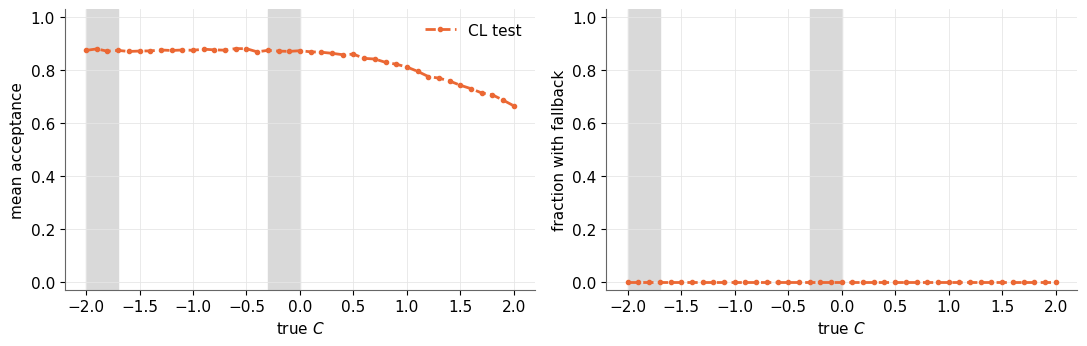

In [3]:
fig = plots.fallback_vs_c(cfg, {f"{LABEL} test": results[f"{LABEL} test"]})
metrics.save_fig(cfg, fig, f"sbi_{KIND}/fallback_vs_C")

## Summary metrics
`err` = |median − true| / prior width, `2sigma` = posterior width / prior width, `bias` = (median − true) / σ, `coverage_68` should be ≈ 0.68, `max_calibration_error` ≈ 0 when calibrated.

In [4]:
table, summary = metrics.metrics_table(cfg, results)
metrics.save_json(cfg, summary, f"sbi_{KIND}/metrics.json")
table

median_err_over_prior  median_2sigma_over_prior  mean_bias  \
set     param                                                               
CL val  A                      0.033                     0.158      0.005   
        B                      0.028                     0.131     -0.044   
        C                      0.107                     0.427      0.549   
CL test A                      0.046                     0.164      0.480   
        B                      0.036                     0.137     -0.361   
        C                      0.263                     0.428     -0.508   

               frac_abs_bias_lt_1  frac_abs_bias_lt_2  coverage_68  \
set     param                                                        
CL val  A                   0.889               0.998        0.790   
        B                   0.877               0.997        0.779   
        C                   0.507               0.990        0.669   
CL test A                   0.710               0.910        0.627   
        B                   0.747               0.949        0.651   
        C                   0.405               0.829        0.441   

               max_calibration_error  
set     param                         
CL val  A                      0.068  
        B                      0.054  
        C                      0.060  
CL test A                      0.150  
        B                      0.143  
        C                      0.446

## Predicted vs true

PosixPath('outputs/full/sbi_latents/true_vs_pred.png')

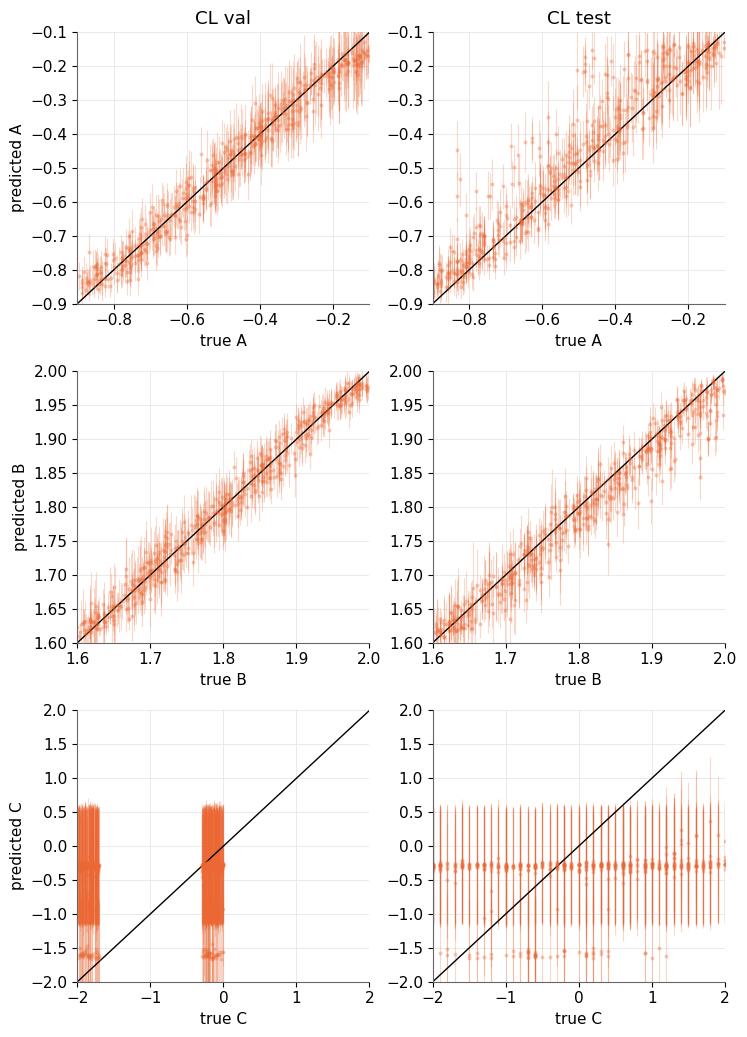

In [5]:
fig = plots.true_vs_pred(cfg, results); metrics.save_fig(cfg, fig, f"sbi_{KIND}/true_vs_pred")

## Error, width and bias distributions (solid = val, dashed = C-grid test)
The first/last bins also collect the values outside the plotted range.

PosixPath('outputs/full/sbi_latents/error_distributions.png')

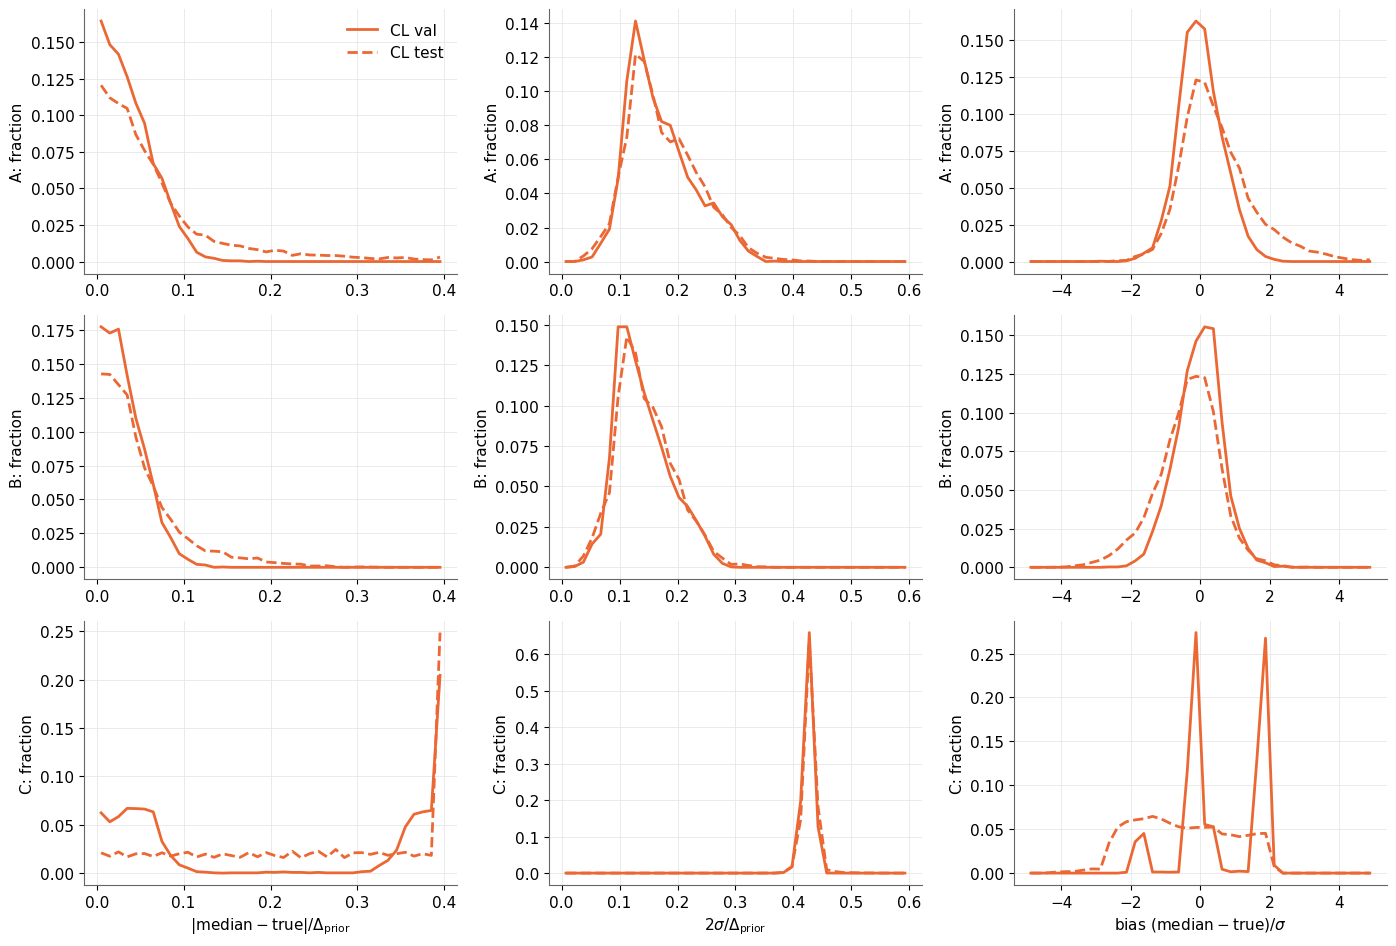

In [6]:
fig = plots.error_distributions(cfg, results); metrics.save_fig(cfg, fig, f"sbi_{KIND}/error_distributions")

## Coverage (calibration)

PosixPath('outputs/full/sbi_latents/coverage.png')

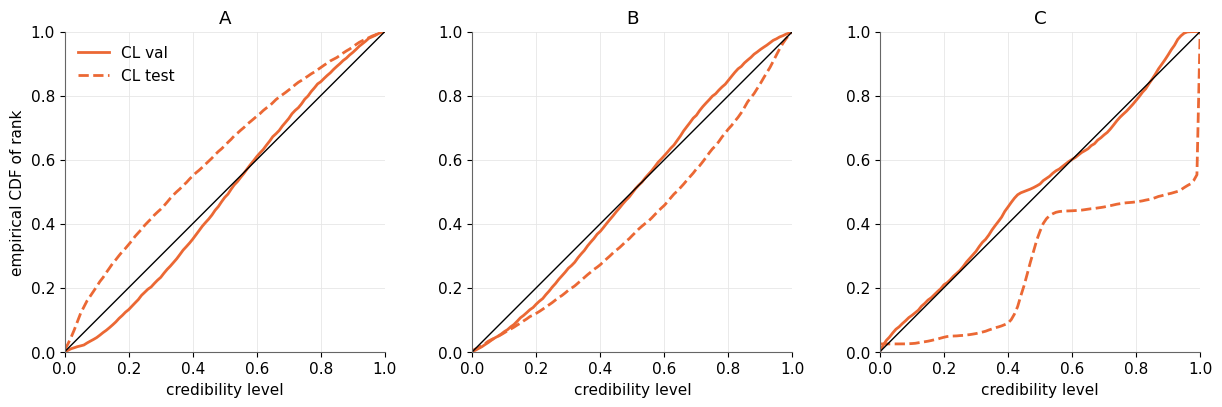

In [7]:
fig = plots.coverage(cfg, results); metrics.save_fig(cfg, fig, f"sbi_{KIND}/coverage")

## Metrics as a function of C (C-grid test set; grey = C ranges seen in training)

PosixPath('outputs/full/sbi_latents/metrics_vs_C.png')

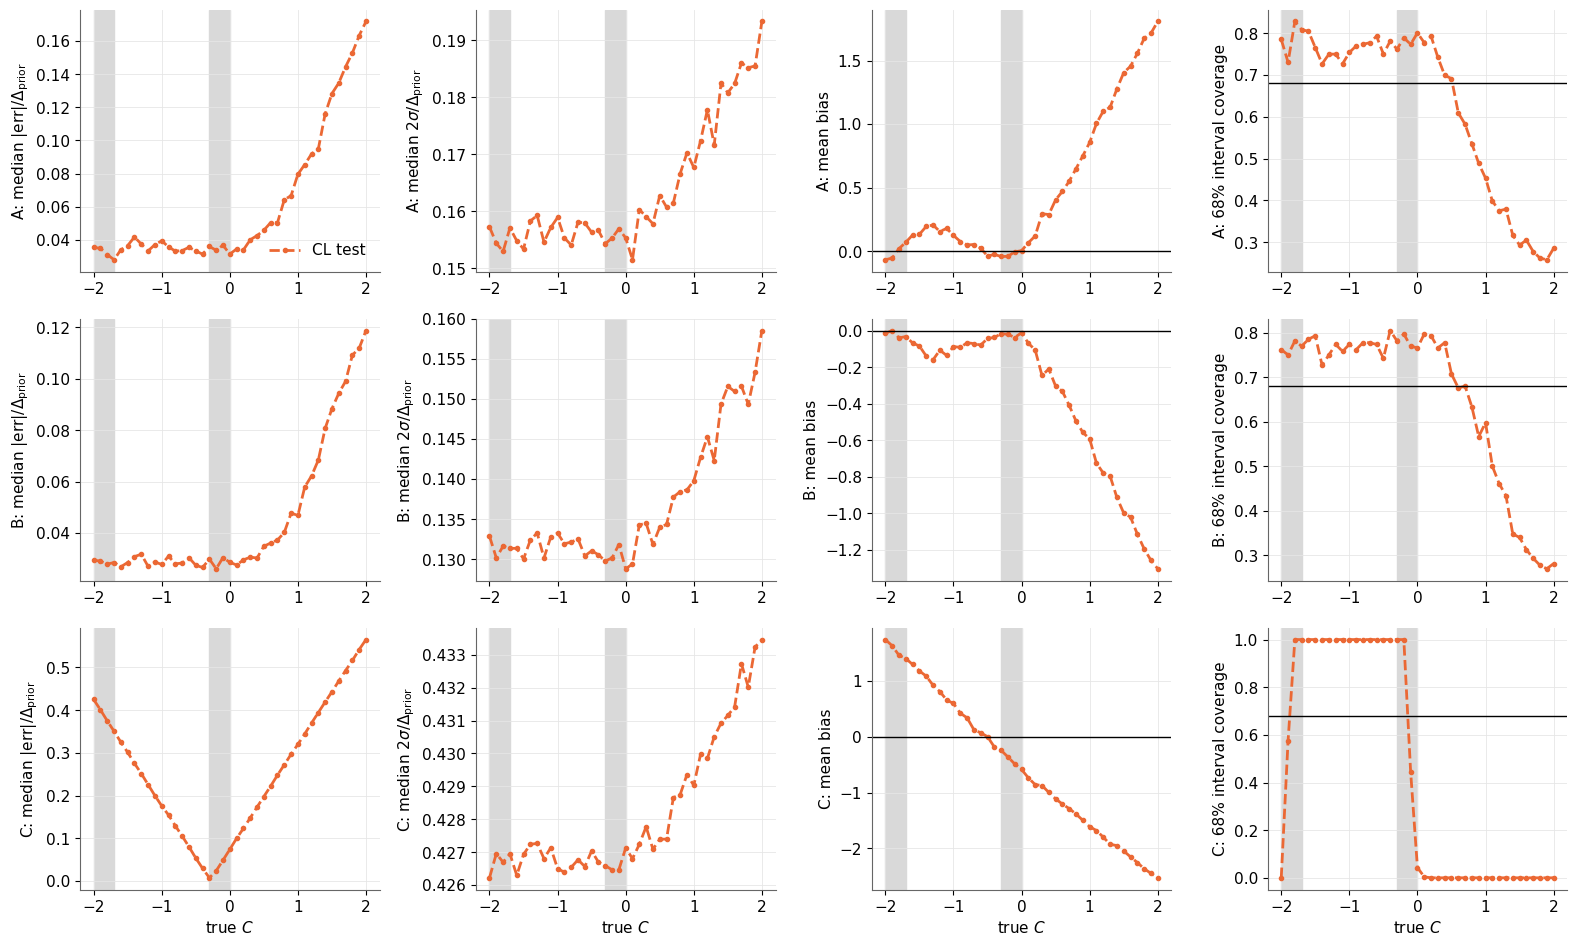

In [8]:
fig = plots.metrics_vs_c(cfg, {f"{LABEL} test": results[f"{LABEL} test"]})
metrics.save_fig(cfg, fig, f"sbi_{KIND}/metrics_vs_C")